# Manim 기초 강의

이 노트북은 Manim의 기초부터 응용까지 순서대로 배우는 강의 자료입니다. 각 섹션은 "설명 → 예제(주석 포함) → 연습 공간" 순서로 구성되어 있습니다.

1. 기본 도형 그리기
2. 색상과 채우기
3. 위치의 기초
4. 다양한 도형 모음
5. 글씨와 수식
6. 그룹으로 묶기
7. 크기와 회전
8. Transform 계열 애니메이션
9. 강조 애니메이션
10. 값 추적과 업데이터
11. 함수 그래프 그리기
12. 표와 행렬
13. 카메라 이동
14. 3D 장면
15. 응용: 전부 조합하기

In [31]:
# 0. 공통 설정 (다른 셀을 실행하기 전에 이 셀을 먼저 실행하세요)

from manim import *  # Scene, MovingCameraScene, Text, Write, FadeIn 등 Manim의 모든 기본 클래스
from manim.utils.ipython_magic import ManimMagic  # 노트북에서 %%manim 매직 커맨드를 쓰기 위한 확장

from pdf_tools import handwritten_text  # 글자를 획(붓 순서) 단위로 쪼개 Write로 손글씨처럼 쓸 수 있게 만드는 함수

# 매직 커맨드(%%manim)를 이 노트북 커널에 등록. 이게 없으면 %%manim 셀이 동작하지 않음
get_ipython().register_magics(ManimMagic)

## 1. 기본 도형 그리기

Manim에서 화면에 그려지는 모든 것(도형, 글자, 이미지 등)을 "mobject"(Manim object)라고 부릅니다.

- `Circle(radius=1, color=WHITE, fill_opacity=0, stroke_width=4)`: 원. `radius`(반지름), `color`(테두리 색), `fill_opacity`(채우기 투명도 0~1), `stroke_width`(테두리 굵기).
- `Square(side_length=2, color=WHITE, fill_opacity=0)`: 정사각형. `side_length`(한 변의 길이).
- `Triangle(color=WHITE, fill_opacity=0)`: 정삼각형. `RegularPolygon`을 상속해 `color`/`fill_opacity` 등 공통 매개변수를 그대로 사용.
- `Line(start=LEFT, end=RIGHT, color=WHITE, stroke_width=4)`: 선분. `start`/`end`(시작·끝 좌표), `stroke_width`(굵기).
- `Dot(point=ORIGIN, radius=0.08, color=WHITE)`: 점. `point`(위치), `radius`(점 크기).

- `self.add(*mobjects)`: 여러 mobject를 한 번에 받아 즉시 표시(애니메이션 없음).- `self.wait(duration=1)`: `duration`(정지 시간, 초).

- `Create(mobject, run_time=1, lag_ratio=1)`: `run_time`(재생 시간, 초), `lag_ratio`(부분별로 순차적으로 그려지는 정도).- `FadeIn(mobject, shift=벡터, scale=배율, run_time=1)`: `shift`(등장하며 이동할 방향), `scale`(등장하며 커지거나 작아지는 정도).

In [36]:
%%manim -ql -v WARNING Section1_BasicShapes
class Section1_BasicShapes(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        # 원: add로 애니메이션 없이 바로 표시
        circle = Circle()
        self.add(circle)
        self.wait(1)

        # 사각형: Create로 테두리를 그리며 등장
        square = Square(color=RED)
        self.play(Create(square))
        self.wait(1)

        # 화면이 복잡해지지 않도록 이전 도형을 지우고 다음 도형을 보여줌
        self.play(FadeOut(circle), FadeOut(square))

        # 삼각형과 선분, 점을 함께 등장
        triangle = Triangle()
        line = Line(start=LEFT * 2, end=RIGHT * 2, color=BLUE)
        dot = Dot(point=ORIGIN, color=GREEN)
        self.play(FadeIn(triangle), Create(line), FadeIn(dot))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section1_Practice
class Section1_Practice(Scene):
    def construct(self):
        # 연습 공간: 다른 도형(Ellipse, Rectangle, Arrow 등)을 add/Create/FadeIn으로 그려보세요.
        pass

## 2. 색상과 채우기

- `color=`: 테두리(선) 색 지정용 매개변수. `RED`, `BLUE`, `GREEN`, `YELLOW`, `WHITE`, `BLACK`, `PURPLE`, `ORANGE`, `TEAL` 등 미리 정의된 색상 상수를 값으로 받습니다.
- `fill_opacity=0~1`: 도형 내부 채우기 투명도(`0`=투명, `1`=완전히 채움). 대부분의 도형 생성자에 공통으로 존재.
- `fill_color=색상`: 테두리 색과 다른 채우기 색을 지정할 때 사용(생략하면 `color`를 그대로 씀).
- `stroke_width=숫자` / `stroke_opacity=0~1`: 테두리의 굵기와 투명도.
- `mobject.set_color(color)`: `color`(바꿀 색상).

- `mobject.set_fill(color=None, opacity=None)`: `color`(채우기 색), `opacity`(채우기 투명도).- `mobject.set_stroke(color=None, width=None, opacity=None)`: 테두리 색/굵기/투명도를 개별적으로 변경.

In [ ]:
%%manim -ql -v WARNING Section2_ColorFill
class Section2_ColorFill(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        # 만들 때 색과 채우기를 함께 지정
        red_square = Square(color=RED, fill_opacity=1)
        blue_circle = Circle(color=BLUE, fill_opacity=0.5)  # 반투명 채우기
        VGroup(red_square, blue_circle).arrange(RIGHT, buff=1)
        self.play(FadeIn(red_square), FadeIn(blue_circle))
        self.wait(1)

        # 나중에 set_color / set_fill로 색을 바꾸기
        self.play(
            red_square.animate.set_color(GREEN),
            blue_circle.animate.set_fill(YELLOW, opacity=1),
        )
        self.wait(1)

In [ ]:
%%manim -ql -v WARNING Section2_Practice
class Section2_Practice(Scene):
    def construct(self):
        # 연습 공간: 색상 상수(PURPLE, ORANGE, TEAL 등)와 fill_opacity 값을 바꿔가며 실험해보세요.
        pass

## 3. 위치의 기초

Manim의 화면 중심 좌표는 `ORIGIN`(= `[0, 0, 0]`)입니다. 방향은 아래 벡터 상수로 표현합니다.

- `UP`, `DOWN`, `LEFT`, `RIGHT`: 각각 위/아래/왼쪽/오른쪽으로 1만큼 이동하는 벡터입니다.
- `RIGHT * 2`처럼 숫자를 곱하면 그 방향으로 거리(배율)를 조절할 수 있고, `UP + RIGHT`처럼 더하면 대각선 방향이 됩니다.
- `mobject.move_to(point_or_mobject, aligned_edge=ORIGIN)`: `point_or_mobject`(이동할 목표 좌표 또는 다른 mobject), `aligned_edge`(정렬 기준 모서리).
- `mobject.shift(*vectors)`: 이동 벡터(들)를 받아 현재 위치에서 상대적으로 이동(누적됨).
- `mobject.to_edge(edge=UP, buff=0.5)`: `edge`(붙일 가장자리 방향), `buff`(가장자리와의 여백).
- `mobject.to_corner(corner=UL, buff=0.5)`: `corner`(붙일 모서리, 예: `UL`=왼쪽 위), `buff`(여백).
- **특정 위치에서 바로 나타나기**: `self.play(FadeIn(...))`나 `self.add(...)`로 화면에 표시하기 *전에* `move_to`/`shift`/`to_edge`로 위치를 먼저 잡아두면, 그 mobject는 원점(중앙)을 거치지 않고 처음부터 그 위치에서 나타납니다. 즉 `Circle().move_to(RIGHT * 3)`처럼 생성 직후 위치를 지정한 뒤 `self.play(FadeIn(...))`를 호출하면 됩니다. 또한 `Dot(point=RIGHT*3)`, `Line(start=..., end=...)`처럼 생성자 자체에 좌표를 넘겨 처음부터 원하는 위치에 만들 수도 있습니다.

In [39]:
%%manim -ql -v WARNING Section3_Position
class Section3_Position(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        dot = Dot(color=BLACK)
        self.add(dot)

        # move_to: 절대 좌표로 이동
        self.play(dot.animate.move_to(UP * 2 + LEFT * 3))
        self.wait(0.3)

        # shift: 현재 위치에서 상대적으로 이동 (2번 연속 적용하면 계속 누적됨)
        self.play(dot.animate.shift(RIGHT * 2))
        self.play(dot.animate.shift(RIGHT * 2))
        self.wait(0.3)

        # to_edge / to_corner: 화면 가장자리/모서리에 붙이기
        square = Square(color=BLUE)
        self.play(FadeIn(square))
        self.play(square.animate.to_edge(DOWN))
        self.wait(0.3)
        self.play(square.animate.to_corner(UR))
        self.wait(1)
        self.play(FadeOut(square))

        # 등장 전에 위치를 먼저 잡아두면, 원점이 아니라 그 위치에서 바로 나타남
        star = Star(color=YELLOW, fill_opacity=1).move_to(LEFT * 4 + DOWN * 2)
        self.play(FadeIn(star))
        self.wait(0.3)

        # 생성자에 좌표를 직접 넘겨도 동일한 효과
        triangle = Triangle(color=GREEN, fill_opacity=1).shift(RIGHT * 4 + UP * 2)
        self.play(Create(triangle))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section3_Practice
class Section3_Practice(Scene):
    def construct(self):
        # 연습 공간: move_to / shift / to_edge / to_corner를 다른 도형에 적용해보세요.
        pass

## 4. 다양한 도형 모음

Manim에는 기본 도형 외에도 다양한 전용 도형 클래스가 있습니다.

- `RegularPolygon(n=6, color=WHITE, fill_opacity=0, start_angle=None)`: 정n각형. `n`(변의 개수), `start_angle`(시작 각도).
- `Star(n=5, outer_radius=1, inner_radius=None, color=WHITE, fill_opacity=0)`: 별 모양. `n`(꼭짓점 개수), `outer_radius`/`inner_radius`(바깥·안쪽 반지름).
- `Ellipse(width=2, height=1, color=WHITE, fill_opacity=0)`: 타원. `width`/`height`(가로·세로 길이).
- `RoundedRectangle(width=2, height=2, corner_radius=0.5, color=WHITE, fill_opacity=0)`: 모서리 둥근 사각형. `corner_radius`(모서리가 둥근 정도).
- `Arc(radius=1, start_angle=0, angle=PI/2, color=WHITE)`: 호. `radius`(반지름), `start_angle`(시작 각도, 라디안), `angle`(호의 각도 범위).
- `Arrow(start=LEFT, end=RIGHT, color=WHITE, buff=0.25, stroke_width=6)`: 화살표. `start`/`end`(시작·끝점), `buff`(끝점과의 여백).

- `DoubleArrow(start=LEFT, end=RIGHT, ...)`: `Arrow`와 동일한 매개변수, 양쪽에 화살촉 생성.- `GrowArrow(arrow, run_time=1)`: 화살표가 자라나는 애니메이션. `run_time`(재생 시간).
- `Polygon(*vertices, color=WHITE, fill_opacity=0)`: 좌표들을 순서대로 받는 가변 인자(`*vertices`)로 다각형 생성.

In [40]:
%%manim -ql -v WARNING Section4_MoreShapes
class Section4_MoreShapes(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        pentagon = RegularPolygon(n=5, color=PURPLE, fill_opacity=1)
        star = Star(n=6, color=GOLD, fill_opacity=1)
        ellipse = Ellipse(width=2, height=1, color=TEAL, fill_opacity=1)
        rounded = RoundedRectangle(corner_radius=0.2, color=MAROON, fill_opacity=1)

        shapes = VGroup(pentagon, star, ellipse, rounded).arrange(RIGHT, buff=0.6)
        self.play(FadeIn(shapes))
        self.wait(1)
        self.play(FadeOut(shapes))

        # 화살표와 자유 다각형(삼각형 모양을 좌표로 직접 지정)
        arrow = Arrow(start=LEFT * 3, end=RIGHT * 3, color=BLACK)
        polygon = Polygon(
            UP * 1.5, LEFT * 1.5 + DOWN, RIGHT * 1.5 + DOWN,
            color=BLUE, fill_opacity=1,
        )
        self.play(GrowArrow(arrow))
        self.play(Create(polygon))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section4_Practice
class Section4_Practice(Scene):
    def construct(self):
        # 연습 공간: RegularPolygon의 n을 바꾸거나, Arc의 각도를 바꿔가며 실험해보세요.
        pass

## 5. 글씨와 수식

- `Text(text, font="", font_size=48, color=WHITE, weight=NORMAL, slant=NORMAL)`: 일반 텍스트. `text`(내용), `font`(글꼴, 한글은 `"NanumGothic"`처럼 설치된 한글 글꼴 필요), `font_size`(크기), `weight`(굵기, 예: `BOLD`), `slant`(기울임, 예: `ITALIC`).
- `MathTex(*tex_strings, color=WHITE, font_size=48, tex_to_color_map={})`: LaTeX 수식 렌더링(문자열 앞에 `r`을 붙여 백슬래시 그대로 전달). `tex_to_color_map`(특정 부분만 다른 색으로 지정하는 딕셔너리). 예: `MathTex(r"x^2 + y^2 = r^2")`.
- `Tex(*tex_strings, color=WHITE, font_size=48)`: 수식이 아닌 일반 LaTeX 텍스트(한글 지원 안 함).
- `Write(mobject, run_time=2, lag_ratio=None)`: 글자 획을 그리듯 등장. `run_time`(재생 시간), `lag_ratio`(글자별 순차 등장 정도).
- `handwritten_text(text, font_size=48)`: `pdf_tools.py`에서 가져온 함수로, 글자를 획 순서대로 쪼개 `Write`로 손글씨처럼 재생. `text`(내용), `font_size`(크기).

In [41]:
%%manim -ql -v WARNING Section5_TextAndMath
class Section5_TextAndMath(Scene):
    def construct(self):
        self.camera.background_color = "#1d2b21"

        title = Text("Manim 기초", font="NanumGothic", font_size=56, color=WHITE)
        self.play(Write(title), run_time=2)
        self.play(title.animate.to_edge(UP), run_time=0.8)

        # 수식은 MathTex로 작성 (r"..." 형태로 LaTeX 문법 사용)
        equation = MathTex(r"x^2 + y^2 = r^2", color=WHITE, font_size=60)
        self.play(Write(equation), run_time=2)
        self.wait(0.5)

        self.play(FadeOut(equation))
        note = handwritten_text("오늘의 수학", font_size=64)
        self.play(Write(note), run_time=2)
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section5_Practice
class Section5_Practice(Scene):
    def construct(self):
        # 연습 공간: 다른 수식(예: 이차방정식 근의 공식)을 MathTex로 써보세요.
        pass

## 6. 그룹으로 묶기

- `VGroup(*mobjects)`: 여러 mobject(도형, 글자 등 벡터 기반)를 가변 인자로 받아 하나로 묶습니다. `Group(*mobjects)`은 이미지(`ImageMobject`)까지 섞어서 묶을 때 사용합니다.
- `group.arrange(direction=RIGHT, buff=0.25, center=True)`: `direction`(정렬 방향), `buff`(간격), `center`(정렬 후 중앙 정렬 여부).
- `group.arrange_in_grid(rows=None, cols=None, buff=0.25)`: `rows`/`cols`(행·열 개수), `buff`(간격).
- `mobject.next_to(mobject_or_point, direction=RIGHT, buff=0.25, aligned_edge=ORIGIN)`: `direction`(붙일 방향), `buff`(간격), `aligned_edge`(정렬 기준).
- 그룹 전체에 `.animate`, `FadeIn`, `move_to` 등을 적용하면 그룹 안의 모든 원소에 동시에 적용됩니다.
- `group[번호]`로 그룹 안의 특정 원소에 개별 접근할 수 있습니다.

In [42]:
%%manim -ql -v WARNING Section6_Grouping
class Section6_Grouping(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        # 정사각형 6개를 만들어 격자로 자동 정렬
        squares = VGroup(*[Square(side_length=0.7, color=BLUE) for _ in range(6)])
        squares.arrange_in_grid(rows=2, cols=3, buff=0.3)
        self.play(FadeIn(squares))
        self.wait(0.5)

        # group[인덱스]로 특정 원소만 골라 색 변경
        self.play(squares[2].animate.set_color(RED))
        self.wait(0.5)

        # 라벨을 next_to로 그룹 아래에 붙이기
        label = Text("사각형 6개", font="NanumGothic", color=BLACK)
        label.next_to(squares, DOWN, buff=0.4)
        self.play(Write(label))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section6_Practice
class Section6_Practice(Scene):
    def construct(self):
        # 연습 공간: arrange_in_grid의 rows/cols를 바꾸거나 group[인덱스]로 다른 원소를 강조해보세요.
        pass

## 7. 크기와 회전

- `mobject.scale(factor, about_point=None)`: `factor`(현재 크기에 곱할 상대 배율, `0.5`는 절반, `2`는 2배), `about_point`(배율 적용 기준점).
- `mobject.scale_to_fit_width(width)` / `.scale_to_fit_height(height)`: 상대 배율이 아닌 절대 폭/높이(`width`/`height`)를 지정.
- `mobject.rotate(angle, axis=OUT, about_point=None)`: `angle`(라디안 단위 회전각, `PI`=180도, `PI/2`=90도, `TAU`=360도), `axis`(회전축, 2D는 기본 `OUT`), `about_point`(회전 기준점).
- `mobject.flip(axis=UP)`: `axis`(반전 기준 축, `UP`/`RIGHT` 등).
- `Rotate(mobject, angle=PI, axis=OUT, about_point=None, run_time=1)`: `.animate.rotate(...)` 대신 사용할 수 있는 회전 전용 애니메이션. 매개변수는 `rotate()`와 동일 + `run_time`.

In [43]:
%%manim -ql -v WARNING Section7_ScaleRotate
class Section7_ScaleRotate(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        square = Square(color=BLUE, fill_opacity=1)
        self.play(FadeIn(square))

        # scale: 상대 배율
        self.play(square.animate.scale(1.5))
        self.wait(0.3)
        self.play(square.animate.scale(1 / 1.5))  # 원래 크기로 복귀
        self.wait(0.3)

        # rotate: 라디안 단위 회전 (PI/4 = 45도)
        self.play(square.animate.rotate(PI / 4))
        self.wait(0.3)

        # Rotate 클래스로도 동일하게 회전 가능
        self.play(Rotate(square, angle=PI / 4))
        self.wait(0.3)

        # scale_to_fit_width: 절대 폭 지정 (현재 크기와 무관하게 항상 같은 결과)
        self.play(square.animate.scale_to_fit_width(3))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section7_Practice
class Section7_Practice(Scene):
    def construct(self):
        # 연습 공간: rotate 각도(PI/6, PI/3 등)나 scale 배율을 바꿔가며 실험해보세요.
        pass

## 8. Transform 계열 애니메이션

"A가 B로 변신"하는 애니메이션입니다.

- `Transform(mobject, target_mobject, run_time=1)`: `mobject`(원본), `target_mobject`(목표 모양), `run_time`. 애니메이션이 끝나도 장면에는 여전히 원본 이름의 mobject만 남습니다(겉모습만 target처럼 보임).
- `ReplacementTransform(mobject, target_mobject, run_time=1)`: 매개변수는 `Transform`과 동일하나, 변신 후 실제로 원본을 지우고 target으로 교체합니다(이후 target을 직접 조작, 실무에서 더 자주 씀).
- `TransformMatchingTex(mobject, target_mobject, transform_mismatches=False)`: `transform_mismatches`(일치하지 않는 부분까지 변형할지 여부). 같은 부분은 그대로 두고 달라진 부분만 움직이며 바뀜(수식 전개 과정에 유용).
- `TransformMatchingShapes(mobject, target_mobject)`: 수식이 아닌 일반 도형에 대해 유사한 방식으로 매칭.

In [ ]:
%%manim -ql -v WARNING Section8_Transform
class Section8_Transform(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        circle = Circle(color=BLUE, fill_opacity=1)
        square = Square(color=RED, fill_opacity=1)
        self.play(FadeIn(circle))

        # ReplacementTransform: circle을 지우고 square로 교체 (이후 square만 사용)
        self.play(ReplacementTransform(circle, square))
        self.wait(0.5)
        self.play(FadeOut(square))

        # TransformMatchingTex: 같은 부분(=, x)은 유지하고 다른 부분만 움직이며 바뀜
        eq1 = MathTex("x", "=", "1", "+", "1").set_color(BLACK)
        eq2 = MathTex("x", "=", "2").set_color(BLACK)
        self.play(Write(eq1))
        self.wait(0.5)
        self.play(TransformMatchingTex(eq1, eq2))
        self.wait(1)

In [ ]:
%%manim -ql -v WARNING Section8_Practice
class Section8_Practice(Scene):
    def construct(self):
        # 연습 공간: 다른 도형끼리, 또는 다른 수식끼리 Transform을 적용해보세요.
        pass

## 9. 강조 애니메이션

특정 mobject에 시선을 집중시키고 싶을 때 사용하는 애니메이션들입니다.

- `Indicate(mobject, scale_factor=1.2, color=YELLOW, run_time=1)`: `scale_factor`(커지는 배율), `color`(반짝이는 색). 잠깐 커졌다가 원래 크기로 돌아오며 색이 반짝입니다.
- `Circumscribe(mobject, shape=Rectangle, color=YELLOW, buff=0.1)`: `shape`(테두리 모양, `Rectangle`/`Circle`), `buff`(여백). 테두리 도형이 그려졌다 사라지며 강조.
- `Wiggle(mobject, scale_value=1.1, rotation_angle=0.01*TAU, n_wiggles=6)`: `scale_value`(흔들릴 때 커지는 정도), `rotation_angle`(흔들림 각도), `n_wiggles`(흔들리는 횟수).
- `Flash(point, color=YELLOW, line_length=0.2, num_lines=12, flash_radius=1.0)`: `point`(위치, 도형이 아니라 좌표도 가능), `line_length`/`num_lines`/`flash_radius`(빛 줄기 모양).
- `FocusOn(point, color=GREY, run_time=2)`: `point`(집중시킬 위치), `color`. 해당 위치로 원이 좁혀 들어오며 시선을 집중시킵니다.

In [44]:
%%manim -ql -v WARNING Section9_Emphasis
class Section9_Emphasis(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        text = Text("중요한 결과", font="NanumGothic", color=BLACK, font_size=48)
        self.play(Write(text))
        self.wait(0.3)

        self.play(Indicate(text, color=RED))
        self.wait(0.3)
        self.play(Circumscribe(text, color=BLUE))
        self.wait(0.3)
        self.play(Wiggle(text))
        self.wait(0.3)
        self.play(Flash(text.get_center(), color=YELLOW))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section9_Practice
class Section9_Practice(Scene):
    def construct(self):
        # 연습 공간: FocusOn을 추가해보거나, 강조 애니메이션 순서를 바꿔보세요.
        pass

## 10. 값 추적과 업데이터

- `ValueTracker(value=0)`: 화면에 보이지 않는 "숫자 상자". `value`(초기값). `.get_value()`(현재 값 읽기, 매개변수 없음), `.animate.set_value(value)`(목표값으로 애니메이션 변경).
- `mobject.add_updater(update_function, call_updater=False)`: `update_function`(매 프레임 실행할 함수, mobject를 인자로 받음). 함수 안에서 `tracker.get_value()`를 읽어 mobject를 계속 갱신하면 트래커 값 변화에 자동으로 따라 움직입니다.
- `DecimalNumber(number=0, num_decimal_places=2, color=WHITE)`: `number`(초기 숫자), `num_decimal_places`(소수점 자리수). updater와 함께 쓰면 실시간으로 변하는 숫자를 만들 수 있습니다.
- `mobject.remove_updater(update_function)` / `mobject.clear_updaters()`: 특정 updater 또는 모든 updater를 해제(장면 마지막에 값을 고정할 때 사용).

In [45]:
%%manim -ql -v WARNING Section10_ValueTracker
class Section10_ValueTracker(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        tracker = ValueTracker(0)

        # 숫자를 표시하는 DecimalNumber, updater로 tracker 값을 계속 따라가게 함
        number = DecimalNumber(0, color=BLACK).scale(2)
        number.add_updater(lambda m: m.set_value(tracker.get_value()))

        # 점도 tracker 값에 따라 오른쪽으로 이동하도록 updater 등록
        dot = Dot(color=BLUE)
        dot.add_updater(lambda m: m.move_to(RIGHT * tracker.get_value()))

        self.add(number, dot)
        self.play(tracker.animate.set_value(5), run_time=3)
        self.wait(0.5)

        # 더 이상 갱신하지 않도록 해제
        number.clear_updaters()
        dot.clear_updaters()
        self.wait(1)

Manim Community v0.21.0

In [54]:
%%manim -ql -v WARNING Section10_Practice
class Section10_Practice(Scene):
    def construct(self):
        # 연습 공간: tracker 목표값을 바꾸거나, updater로 회전 각도를 추적해보세요.
        self.camera.background_color = WHITE
        
        tracker = ValueTracker(0)

        # 변수명을 Text 클래스와 겹치게 지으면 UnboundLocalError가 발생하므로 다른 이름 사용
        label = Text("0", font_size=48, color=BLACK)
        # Text에는 set_text가 없어 내용을 바꿀 수 없으므로, become으로 매 프레임 새 Text로 교체
        label.add_updater(
            lambda m: m.become(Text(f"{tracker.get_value():.2f}", font_size=48, color=BLACK))
        )
        self.add(label)
        self.play(tracker.animate.set_value(1), run_time=2)
        self.wait()

Manim Community v0.21.0

## 11. 함수 그래프 그리기

- `Axes(x_range=[-1,1,1], y_range=[-1,1,1], x_length=None, y_length=None, axis_config={}, tips=True)`: `x_range`/`y_range`(각각 [최소,최대,간격]), `x_length`/`y_length`(축의 실제 화면 길이), `axis_config`(두 축 공통 스타일), `tips`(축 화살촉 표시 여부).
- `x_axis_config={"tip_shape": StealthTip, "tip_length": 0.25, "tip_width": 0.18}` / `y_axis_config=...`: x축/y축에만 적용되는 설정. `tip_shape`(화살촉 모양: `ArrowTriangleFilledTip`, `ArrowTriangleTip`, `StealthTip`, `ArrowSquareTip` 등), `tip_length`(길이), `tip_width`(폭).
- `axes.plot(function, x_range=None, color=WHITE)`: `function`(파이썬 함수, 예: `lambda x: x**2`), `x_range`(그릴 구간, 생략 시 축의 x_range 사용).
- `axes.get_graph_label(graph, label="f(x)", direction=RIGHT, buff=0.1)`: `graph`(대상 그래프), `label`(라벨 내용), `direction`/`buff`(라벨 위치·여백).
- `axes.get_area(graph, x_range=None, color=BLUE, opacity=0.5)`: `x_range`(넓이를 구할 구간), `color`/`opacity`(색·투명도).
- `axes.coords_to_point(*coords)`: 좌표값(x, y 등)을 받아 실제 화면 좌표로 변환.
- `Create(graph, run_time=1)`: `run_time`(그래프가 그려지는 시간).

In [95]:
%%manim -ql -v WARNING Section11_Graphs
class ThinTriangleTip(ArrowTriangleTip):
    # ArrowTriangleTip은 tip_width가 자동 전달되지 않아 width를 직접 강제 적용
    def __init__(self, length=0.22, width=0.09, **kwargs):
        width = kwargs.pop("width", width)
        super().__init__(length=length, **kwargs)
        self.stretch_to_fit_width(length)
        self.stretch_to_fit_height(width)


class Section11_Graphs(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        # PDF 20번 문제: f(x)=sin x, g(x)=-k cos x (k>1). k=1.5로 예시 도형 재현
        k = 1.5
        t = np.arctan(k)  # A, B, C, D의 x좌표를 구하는 데 쓰이는 각
        guide_y = k / np.sqrt(1 + k**2)  # 두 교점(A, B)의 y좌표 크기

        x_min, x_max = -0.35, 2 * PI + 0.5

        axes = Axes(
            x_range=[x_min - 0.2, x_max + 0.2, PI / 2],
            y_range=[-1.6, 1.6, 0.5],
            x_length=10,
            y_length=4.2,
            axis_config={
                "color": BLACK,
                "stroke_width": 1.5,
                "include_numbers": False,
                "include_ticks": False,
                "tip_shape": ThinTriangleTip,
                "tip_length": 0.22,
                "tip_style": {"width": 0.09},
            },
            tips=True,
        )
        axes.move_to(ORIGIN)

        upper_line = Line(
            axes.coords_to_point(x_min, guide_y),
            axes.coords_to_point(x_max, guide_y),
            color=BLACK, stroke_width=1.5,
        )
        lower_line = Line(
            axes.coords_to_point(x_min, -guide_y),
            axes.coords_to_point(x_max, -guide_y),
            color=BLACK, stroke_width=1.5,
        )

        f_graph = axes.plot(lambda x: np.sin(x), x_range=[x_min, x_max], color=BLACK, stroke_width=2)
        g_graph = axes.plot(lambda x: -k * np.cos(x), x_range=[x_min, x_max], color=BLACK, stroke_width=2)

        x_label = MathTex("x", color=BLACK).scale(0.8).next_to(axes.x_axis.get_end(), RIGHT, buff=0.1)
        y_label = MathTex("y", color=BLACK).scale(0.8).next_to(axes.y_axis.get_end(), UP, buff=0.1)
        origin_label = MathTex("O", color=BLACK).scale(0.7).move_to(axes.c2p(0, 0) + DOWN * 0.3 + LEFT * 0.18)
        two_pi_label = MathTex("2\\pi", color=BLACK).scale(0.7).next_to(axes.c2p(2 * PI, 0), DOWN, buff=0.1)

        f_label = MathTex("y=f(x)", color=BLACK).scale(0.75).move_to(axes.c2p(0.9, 1.15))
        g_label = MathTex("y=g(x)", color=BLACK).scale(0.75).move_to(axes.c2p(3.45, k + 0.2))

        # A, B는 f=g 교점, C, D는 g(x)가 같은 높이에서 다시 만나는 점
        point_A = axes.c2p(PI - t, guide_y)
        point_C = axes.c2p(PI + t, guide_y)
        point_D = axes.c2p(t, -guide_y)
        point_B = axes.c2p(2 * PI - t, -guide_y)

        label_A = MathTex("A", color=BLACK).scale(0.75).next_to(point_A, UP, buff=0.1)
        label_C = MathTex("C", color=BLACK).scale(0.75).next_to(point_C, UP, buff=0.1)
        label_D = MathTex("D", color=BLACK).scale(0.75).next_to(point_D, DOWN, buff=0.1)
        label_B = MathTex("B", color=BLACK).scale(0.75).next_to(point_B, DOWN, buff=0.1)

        self.play(Create(axes))
        self.play(Create(upper_line), Create(lower_line))
        self.play(Create(f_graph), Create(g_graph), run_time=2)
        self.play(
            Write(x_label), Write(y_label), Write(origin_label), Write(two_pi_label),
            Write(f_label), Write(g_label),
            Write(label_A), Write(label_B), Write(label_C), Write(label_D),
        )
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section11_Practice
class Section11_Practice(Scene):
    def construct(self):
        # 연습 공간: 다른 함수(sin, cos, x**3 등)를 그려보거나 x_range를 바꿔보세요.
        pass

## 12. 표와 행렬

- `Table(table, row_labels=None, col_labels=None, include_outer_lines=False)`: `table`(2차원 리스트), `row_labels`/`col_labels`(mobject 리스트), `include_outer_lines`(바깥 테두리 표시 여부). `IntegerTable`, `DecimalTable`은 숫자 표 전용 버전(매개변수 동일).
- `Matrix(matrix, left_bracket="[", right_bracket="]")`: `matrix`(2차원 리스트), `left_bracket`/`right_bracket`(괄호 모양).
- `table.get_entries(pos=None)` / `.get_rows()` / `.get_columns()`: `pos`((행,열) 튜플, 1부터 시작)로 특정 셀에 접근하여 강조·색칠 가능.
- `Create(table, run_time=1)`: 표의 선과 내용이 순서대로 그려지는 애니메이션.

In [70]:
%%manim -ql -v WARNING Section12_TableMatrix
class Section12_TableMatrix(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        table = Table(
            [["1", "2"], ["3", "4"]],
            row_labels=[Text("행1"), Text("행2")],
            col_labels=[Text("A"), Text("B")],
        ).set_color(BLACK)
        table.scale(0.8).to_edge(LEFT)
        self.play(Create(table))
        self.wait(0.5)

        # 특정 셀만 강조 (get_entries는 1부터 시작하는 (행, 열) 좌표)
        self.play(table.get_entries((1, 1)).animate.set_color(RED))
        self.wait(0.5)

        matrix = Matrix([[1, 2], [3, 4]]).set_color(BLACK)
        matrix.to_edge(RIGHT)
        self.play(Write(matrix))
        self.wait(1)

Manim Community v0.21.0

Manim Community v0.21.0

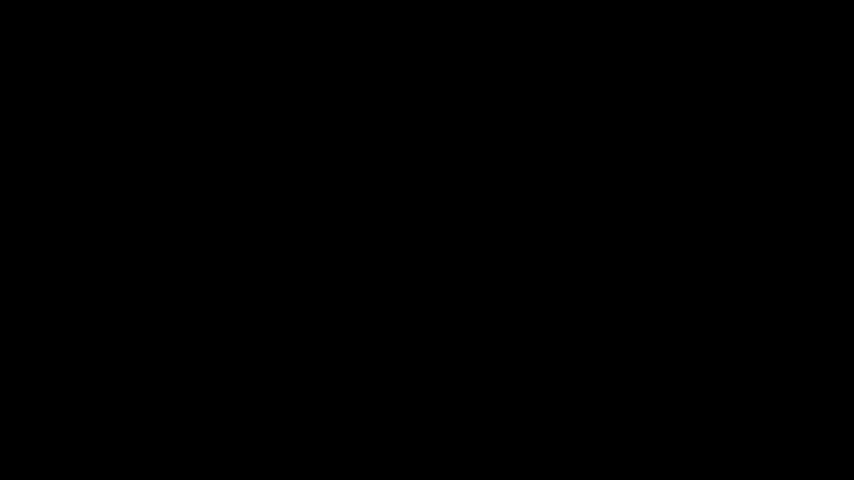

In [71]:
%%manim -ql -v WARNING Section12_Practice
class Section12_Practice(Scene):
    def construct(self):
        # 연습 공간: 행/열 개수를 늘려보거나 IntegerTable로 바꿔보세요.
        pass

## 13. 카메라 이동

`Scene` 대신 `MovingCameraScene`을 상속하면 카메라(보는 화면 자체)를 움직일 수 있습니다.

- `self.camera.frame`: 카메라가 보고 있는 사각형 영역을 나타내는 mobject(매개변수 없는 속성). 이걸 움직이면 화면 전체가 움직이는 것처럼 보입니다.
- `camera.frame.animate.move_to(point_or_mobject)`: `point_or_mobject`(이동할 목표 좌표 또는 mobject, 줌인 대상 따라가기).
- `camera.frame.animate.scale(factor)`: `factor`(배율, 1보다 작으면 확대/줌인, 크면 축소/줌아웃).
- `camera.frame.animate.shift(vector)`: `vector`(상대 이동 벡터).
- 카메라를 원래대로 되돌리려면 `camera.frame.animate.move_to(ORIGIN).scale(1/factor)`처럼 반대 동작을 적용합니다.

In [72]:
%%manim -ql -v WARNING Section13_MovingCamera
class Section13_MovingCamera(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE

        left_circle = Circle(color=BLUE, fill_opacity=1).shift(LEFT * 4)
        right_square = Square(color=RED, fill_opacity=1).shift(RIGHT * 4)
        self.add(left_circle, right_square)
        self.camera.frame.move_to(left_circle)

        self.wait(0.5)
        # 카메라가 왼쪽 원에서 오른쪽 사각형으로 이동
        self.play(self.camera.frame.animate.move_to(right_square))
        self.wait(0.5)

        # 카메라를 확대(줌인)
        self.play(self.camera.frame.animate.scale(0.5))
        self.wait(0.5)

        # 원래 크기로 되돌리고 전체가 보이도록 원점으로 복귀
        self.play(self.camera.frame.animate.scale(2).move_to(ORIGIN))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section13_Practice
class Section13_Practice(MovingCameraScene):
    def construct(self):
        # 연습 공간: 카메라 이동 경로나 확대/축소 배율을 바꿔보세요.
        pass

## 14. 3D 장면

`Scene` 대신 `ThreeDScene`을 상속하면 입체 도형과 3D 시점을 다룰 수 있습니다.

- `self.set_camera_orientation(phi=0, theta=-90*DEGREES, zoom=1)`: `phi`(위/아래 각도), `theta`(좌우 각도), `zoom`(확대 배율).
- `self.begin_ambient_camera_rotation(rate=0.2)` / `self.stop_ambient_camera_rotation()`: `rate`(회전 속도)로 카메라가 자동으로 천천히 회전.
- `ThreeDAxes(x_range=[-1,1,1], y_range=[-1,1,1], z_range=[-1,1,1])`: 3차원 좌표축, 각 축의 range.
- `Sphere(radius=1, resolution=(24,48), fill_opacity=1, checkerboard_colors=[BLUE_D, BLUE_E])`: `radius`(반지름), `resolution`(면 분할 정도), `checkerboard_colors`(체크무늬 색).
- `Cube(side_length=2, fill_opacity=1)`, `Cone(base_radius=1, height=1)`, `Cylinder(radius=1, height=2)`: 각각 크기 관련 매개변수(`side_length`/`base_radius`+`height`/`radius`+`height`).
- `Surface(func, u_range=[0,1], v_range=[0,1], resolution=(32,32))`: `func`(u,v를 받아 3D 좌표를 반환하는 함수), `u_range`/`v_range`(매개변수 범위), `resolution`(곡면 분할 정도)로 곡면(예: 안장면, 구면)을 그립니다.

In [73]:
%%manim -ql -v WARNING Section14_ThreeD
class Section14_ThreeD(ThreeDScene):
    def construct(self):
        self.camera.background_color = WHITE

        axes = ThreeDAxes()
        # phi: 위에서 내려다보는 각도, theta: 좌우로 도는 각도
        self.set_camera_orientation(phi=65 * DEGREES, theta=-45 * DEGREES)
        self.play(Create(axes))

        sphere = Sphere(radius=1, fill_opacity=0.7, checkerboard_colors=[BLUE_D, BLUE_E])
        self.play(FadeIn(sphere))

        # 카메라가 천천히 자동 회전
        self.begin_ambient_camera_rotation(rate=0.3)
        self.wait(3)
        self.stop_ambient_camera_rotation()
        self.wait(0.5)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Section14_Practice
class Section14_Practice(ThreeDScene):
    def construct(self):
        # 연습 공간: Sphere를 Cube나 Cone으로 바꿔보거나 카메라 각도를 바꿔보세요.
        pass

## 15. 응용: 전부 조합하기

지금까지 배운 도형, 색, 위치, 글씨/수식, 그룹, Transform, 강조, 값 추적, 그래프, 카메라 이동 기법을 하나의 장면에 조합한 종합 예제입니다. 각 기법에서 사용한 매개변수는 앞선 1~13절을 참고하세요.

In [82]:
%%manim -ql -v WARNING Section15_FinalCombo
class Section15_FinalCombo(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE

        title = Text("Manim 종합 예제", font="NanumGothic", color=BLACK, font_size=48)
        self.play(Write(title))
        self.play(title.animate.to_edge(UP))

        # 도형 + 색 + 그룹
        shapes = VGroup(
            Circle(color=BLUE, fill_opacity=1),
            Square(color=RED, fill_opacity=1),
            Triangle(color=GREEN, fill_opacity=1),
        ).arrange(RIGHT, buff=0.8)
        self.play(FadeIn(shapes))
        self.play(Circumscribe(shapes[1]))  # 강조

        # Transform: 사각형이 별로 변신
        star = Star(n=5, color=GOLD, fill_opacity=1).move_to(shapes[1])
        self.play(ReplacementTransform(shapes[1], star))
        self.wait(0.5)
        self.play(FadeOut(shapes[0]), FadeOut(shapes[2]), FadeOut(star), FadeOut(title))

        # 그래프 + 값 추적
        axes = Axes(x_range=[-3, 3, 1], y_range=[-1, 9, 1], axis_config={"color": BLACK})
        graph = axes.plot(lambda x: x**2, color=BLUE)
        self.play(Create(axes), Create(graph))

        tracker = ValueTracker(-3)
        moving_dot = Dot(color=RED)
        moving_dot.move_to(axes.coords_to_point(-3, 9))
        moving_dot.add_updater(
            lambda m: m.move_to(axes.coords_to_point(tracker.get_value(), tracker.get_value() ** 2))
        )
        self.add(moving_dot)

        # 점 위치로 부드럽게 이동하면서 동시에 줌인
        self.play(
            self.camera.frame.animate.move_to(moving_dot).scale(0.55),
            run_time=1.5,
            rate_func=smooth,
        )
        self.camera.frame.add_updater(lambda frame: frame.move_to(moving_dot))
        self.play(tracker.animate.set_value(3), run_time=3, rate_func=smooth)
        self.camera.frame.clear_updaters()
        self.wait(1)

Manim Community v0.21.0